# Model

Unlike probabilistic models (like Naive Bayes), a Support Vector Machine (SVM) is a geometric classifier. It seeks to find a high-dimensional hyperplane that perfectly separates the classes while maximizing the "margin" (the distance between the boundary and the closest data points). 

Because the standard SVM algorithm is strictly binary, scaling it to our 10-digit MNIST problem requires a wrapper architecture and a custom optimization loop.

### 1. The Binary Base Model (`CustomLinearSVM`)
Our base estimator is a linear SVM optimized using **Stochastic Gradient Descent (SGD)**. 
We mathematically define our labels as $y \in \{-1, 1\}$. The model attempts to minimize the **Hinge Loss** coupled with **L2 Regularization** to prevent overfitting.

For every single image $x_i$ during an epoch, we calculate the raw decision projection $f_i = w^T x_i + b$. We then evaluate the margin condition:
* **Margin Respected ($y_i \cdot f_i \ge 1$):** The point is correctly classified and safely away from the boundary. We only apply "weight decay" via our regularization parameter ($\lambda$) to keep weights small:
  $w = w - \alpha (\lambda \cdot w)$
* **Margin Violated ($y_i \cdot f_i < 1$):** The point is misclassified or sitting inside the margin. We adjust the weights and bias in the direction of the error, penalized by $\lambda$:
  $w = w - \alpha (\lambda \cdot w - y_i \cdot x_i)$
  $b = b + \alpha \cdot y_i$

*(Where $\alpha$ is the `learning_rate` and $\lambda$ is `lambda_param`).*

### 2. The Multi-Class Strategy (`OneVsRestSVM`)
To handle 10 discrete classes using binary classifiers, we implement the **One-vs-Rest (OvR)** ensemble approach:
1. **Training:** The algorithm initializes 10 separate `CustomLinearSVM` models. Model 0 learns to separate "Digit 0" from "All other digits." Model 1 separates "Digit 1" from all others, and so on.
2. **Prediction (The Argmax Rule):** When a new, unseen image is evaluated, it is passed through all 10 trained equations. Instead of looking at a binary yes/no, we extract the raw continuous scalar output ($w^T x + b$) from each model. This number represents the geometric distance from the hyperplane. 
3. The class whose model outputs the highest positive distance is declared the winner using `np.argmax`.

In [9]:
import numpy as np

class CustomLinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters        
        self.w = None
        self.b = None

    def fit(self, X, y):
        
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        y_mirrored = np.where(y <= 0, -1, 1)

        for epoch in range(self.n_iters):
            
            for idx, x_i in enumerate(X):
                
                y_i = y_mirrored[idx]
                f_i= np.dot((self.w).T, x_i)+self.b

                if f_i * y_i <1:
                    self.w=self.w-self.lr*(self.lambda_param*self.w - y_i*x_i)
                    self.b = self.b + self.lr * y_i
                
                else:
                    self.w=self.w-self.lr*self.lambda_param*self.w 

                
              

    def predict(self, X):
       linear_output = np.dot(X, self.w) + self.b
       prediction = np.where(linear_output >= 0, 1, 0)
       return prediction
       


class OneVsRestSVM:
    def __init__(self, n_classes=10, learning_rate=0.001, lambda_param=0.01, n_iters=50):
        self.n_classes = n_classes
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.models = []

    def fit(self, X, y):
        for i in range(self.n_classes):
            print(f"    Training binary model for Class {i} vs Rest...")
            
            y_binary = np.where(y == i, 1, 0)
            
            binary_model = CustomLinearSVM(
                learning_rate=self.lr, 
                lambda_param=self.lambda_param, 
                n_iters=self.n_iters
            )
            binary_model.fit(X, y_binary)
            self.models.append(binary_model)

    def predict(self, X):
        n_samples = X.shape[0]
        scores = np.zeros((n_samples, self.n_classes))
        
        for i, model in enumerate(self.models):
            raw_value = np.dot(X, model.w) + model.b
            scores[:, i] = raw_value
        
        winning_classes = np.argmax(scores, axis=1)
        return winning_classes

# Cross Validation

To achieve the best possible performance for our One-vs-Rest Linear SVM, we need to optimize both the **feature extraction method** and the **internal hyperparameters** (learning rate, lambda penalty, and iterations). 

Testing every combination on the full 60,000-image dataset would require 120 separate training runs (5 features × 8 hyperparameter combos × 3 folds), which is highly computationally expensive. To solve this, we implement a **Fast Grid Search Strategy**:

1. **Data Subsampling (5%):** We randomly sample just 5% of our combined training and validation data (3,000 images). Because this sample is randomly drawn, it accurately represents the complex distribution of all 10 digits. The hyperparameter combination that performs best on 3,000 images will reliably be the same combination that performs best on 60,000 images, reducing our search time from hours to minutes.
2. **Feature Sweeping:** We dynamically iterate through all our engineered representations (`cnn`, `hog`, `pca`, `flatten`, `hog_pca`) to scientifically prove which representation space makes the classes most linearly separable.
3. **3-Fold Cross-Validation:** Instead of a static train/validation split, the data is split into 3 folds. The model trains on 2 folds and validates on the 3rd, rotating until all folds have been tested. The **Macro F1-Score** is averaged across all 3 folds to guarantee the model is truly generalizing and not just overfitting to a lucky data split. 

*Note: The test set is completely excluded from this process to prevent data leakage. Once this search identifies the optimal feature method and hyperparameters, we will train one final model on the full 100% training dataset using those exact settings.*

In [10]:
import numpy as np
import time
from preprocessing2 import custom_macro_f1_score, k_fold_indices, preprocess

feature_methods = [ "hog_pca", "flatten", "pca","hog", "cnn"]

param_grid = {
    'learning_rate': [0.001, 0.005],
    'lambda_param': [0.01, 0.0001],
    'n_iters': [100, 500]
}

best_f1_score = 0
best_params = {}

total_runs = len(feature_methods) * len(param_grid['learning_rate']) * len(param_grid['lambda_param']) * len(param_grid['n_iters'])
current_run = 1

start_total_time = time.time()

for feature_method in feature_methods:
    print(f"\n{'='*60}")
    print(f" EXTRACTING & TESTING FEATURES: {feature_method.upper()}")
    print(f"{'='*60}")
    
    X_train_full, y_train_full, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=feature_method,
        cv=True,
        n_pca=50
    )

    np.random.seed(42)
    subset_size = int(len(X_train_full) * 0.05) #3000 from 60,000
    indices = np.random.choice(len(X_train_full), subset_size, replace=False)

    X_train_sub = X_train_full[indices]
    y_train_sub = y_train_full[indices]

    folds = k_fold_indices(X_train_sub, k=3)

    for lr in param_grid['learning_rate']:
        for lam in param_grid['lambda_param']:
            for iters in param_grid['n_iters']:
                print(f"--- Run {current_run}/{total_runs} [Feature:{feature_method} | LR:{lr} | Lam:{lam} | Iters:{iters}] ---")
                
                fold_f1_scores = []            
                for fold_num, (train_idx, val_idx) in enumerate(folds):
                    
                    X_fold_train, y_fold_train = X_train_sub[train_idx], y_train_sub[train_idx]
                    X_fold_val, y_fold_val = X_train_sub[val_idx], y_train_sub[val_idx]
                    
                    cv_model = OneVsRestSVM(n_classes=10, learning_rate=lr, lambda_param=lam, n_iters=iters)
                    cv_model.fit(X_fold_train, y_fold_train)
                    
                    preds = cv_model.predict(X_fold_val)
                    fold_f1 = custom_macro_f1_score(y_fold_val, preds, n_classes=10)
                    fold_f1_scores.append(fold_f1)
                
                avg_f1 = np.mean(fold_f1_scores)
                print(f"    -> 3-Fold Avg Macro F1: {avg_f1:.4f}")
                
                if avg_f1 > best_f1_score:
                    best_f1_score = avg_f1
                    best_params = {
                        'feature_method': feature_method, 
                        'learning_rate': lr, 
                        'lambda_param': lam, 
                        'n_iters': iters
                    }
                    
                current_run += 1

print("\n" + "="*50)
print("  ULTIMATE CV GRID SEARCH COMPLETE")
print("="*50)
print(f"Total time taken: {(time.time() - start_total_time) / 60:.2f} minutes")
print(f"Highest CV Macro F1: {best_f1_score:.4f}")
print(f"Winning Parameters:  {best_params}")


 EXTRACTING & TESTING FEATURES: HOG_PCA
--- Run 1/40 [Feature:hog_pca | LR:0.001 | Lam:0.01 | Iters:100] ---
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Trai

## Testing
#### Best  Prameters used:
    Winning Parameters:  {'feature_method': 'hog', 'learning_rate': 0.005, 'lambda_param': 0.0001, 'n_iters': 500}


1. **Model Instantiation:** We initialize the SVM using the absolute best parameters discovered during our sweep.
2. **Definitive Training:** We train this optimized model on the training dataset.
3. **Validation Sanity Check:** We first evaluate the model against the Validation set to ensure the metrics align with our Cross-Validation expectations. 
4. **The Test:** Finally, we expose the model to the perfectly preserved, completely unseen Test Set (10,000 images). This produces our final, unbiased metrics (Accuracy, Precision, Recall, Macro F1-Score, and a 10x10 Confusion Matrix) which will be reported as the official performance of our Phase 2 architecture.

In [ ]:
from preprocessing2 import custom_classification_report, custom_confusion_matrix,preprocess



X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="hog")

final_ovr_hog_svm = OneVsRestSVM(
    n_classes=10, 
    learning_rate=0.005, 
    lambda_param=0.0001, 
    n_iters=500
)

final_ovr_hog_svm.fit(X_train, y_train)
final_test_preds_cnn = final_ovr_hog_svm.predict(X_val)

print("\n" + "="*50)
print(" Val PERFORMANCE (hog)")
print("="*50)

target_names = [f"Digit {i}" for i in range(10)]
print(custom_classification_report(y_val, final_test_preds_cnn, target_names=target_names))

print("\nConfusion Matrix:")
print(custom_confusion_matrix(y_val, final_test_preds_cnn, n_classes=10))

final_test_preds_cnn = final_ovr_hog_svm.predict(X_test)

print("\n" + "="*50)
print(" TEST PERFORMANCE (hog)")
print("="*50)

target_names = [f"Digit {i}" for i in range(10)]
print(custom_classification_report(y_test, final_test_preds_cnn, target_names=target_names))

print("\nConfusion Matrix:")
print(custom_confusion_matrix(y_test, final_test_preds_cnn, n_classes=10))


    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...

 Val PERFORMANCE (hog)
                 precision     recall   f1-score    support

Digit 0               0.98       0.99       0.99        587
Digit 1               0.99       0.99       0.99        630
Digit 2               0.98       0.98       0.98        600
Digit 3               0.96       0.98       0.97        627
Digit 4               0.96       0.97       0.97        595
Digit 5               0.99       0.97       0.98        549
Digit 6               0.99       0.99       0.99        571
Digit

### CNN

Following our  Cross-Validation Grid Search, The grid search  identified the absolute optimal hyperparameters for our One-vs-Rest SVM using cnn as:
* **Learning Rate:** `0.005`
* **Lambda Penalty (Regularization):** `0.0001`
* **Iterations:** `500`

### Scaling to the Full Dataset via Colab Caching
During the hyperparameter tuning phase, we relied on a 5% data subsample to keep compute times manageable. Now, for the final model, we must train on the **entire dataset**. 

Normally, passing 60,000 images through a Deep Convolutional Neural Network on a local CPU would create a massive computational bottleneck, taking hours just to extract the features. However, because we offloaded the CNN forward-pass to a **Google Colab T4 GPU** and securely cached the 512-dimensional output vectors into a highly compressed `.npz` file, we completely bypassed this limitation. 

By loading these cached features directly into memory, we can train our custom mathematical SVM on the **full 100% training dataset** in much shorter time. 

### Execution
This cell instantiates the final SVM with the optimal parameters for cnn, trains it on the full training array, performs a sanity check against the Validation set, and finally evaluates it against the locked 10,000-image **Test Set** .

In [12]:
from preprocessing2 import custom_classification_report, custom_confusion_matrix,preprocess



X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="cnn")

final_ovr_cnn_svm = OneVsRestSVM(
    n_classes=10, 
    learning_rate=0.005, 
    lambda_param=0.0001, 
    n_iters=500
)

final_ovr_cnn_svm.fit(X_train, y_train)
final_test_preds_cnn = final_ovr_cnn_svm.predict(X_val)

print("\n" + "="*50)
print(" Val PERFORMANCE (CNN)")
print("="*50)

target_names = [f"Digit {i}" for i in range(10)]
print(custom_classification_report(y_val, final_test_preds_cnn, target_names=target_names))

print("\nConfusion Matrix:")
print(custom_confusion_matrix(y_val, final_test_preds_cnn, n_classes=10))

final_test_preds_cnn = final_ovr_cnn_svm.predict(X_test)

print("\n" + "="*50)
print(" TEST PERFORMANCE (CNN)")
print("="*50)

target_names = [f"Digit {i}" for i in range(10)]
print(custom_classification_report(y_test, final_test_preds_cnn, target_names=target_names))

print("\nConfusion Matrix:")
print(custom_confusion_matrix(y_test, final_test_preds_cnn, n_classes=10))


CNN Features Loaded: Train=54000, Val=6000, Test=10000
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...

 Val PERFORMANCE (CNN)
                 precision     recall   f1-score    support

Digit 0               1.00       0.95       0.97        587
Digit 1               0.99       0.96       0.97        630
Digit 2               0.95       0.71       0.81        600
Digit 3               0.98       0.58       0.73        627
Digit 4               0.73       0.97       0.84        595
Digit 5               0.76       0.91       0.82        549
Digit 6   

### Bias-Variance Diagnosis: Learning Curve Analysis

The generated learning curve evaluates the performance of the Custom OvR Linear SVM trained on 512-dimensional VGG16 features. By plotting the accuracy scores against the volume of training data used, we can officially diagnose the model's bias-variance tradeoff.

**Key Observations:**
* **Initial Overfitting:** At 10% data volume, the model exhibits high variance. The training accuracy is exceptionally high (~97%) while validation accuracy is at its lowest (~86%), indicating the model is memorizing the small dataset rather than generalizing.
* **Convergence:** As the training volume increases, the training accuracy naturally decays while the validation accuracy stabilizes and climbs. 
* **Final State (Good Fit):** At 100% data volume, the training and validation curves tightly converge in the 86%-88% range. The absence of a large gap between the two curves proves the model is **not overfitting**.

**Engineering Conclusion:**
The model exhibits a well-balanced fit and generalizes properly to unseen data. However, because both curves plateau and converge below the 90% threshold, it indicates a slight limitation in model capacity (High Bias). A pure linear hyperplane is fundamentally limited in its ability to separate highly abstract, non-fine-tuned Deep Learning spatial features, establishing ~86% as the mathematical ceiling for this specific architectural combination.

Training on 5400 samples (10%)...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...
Training on 21600 samples (40%)...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...


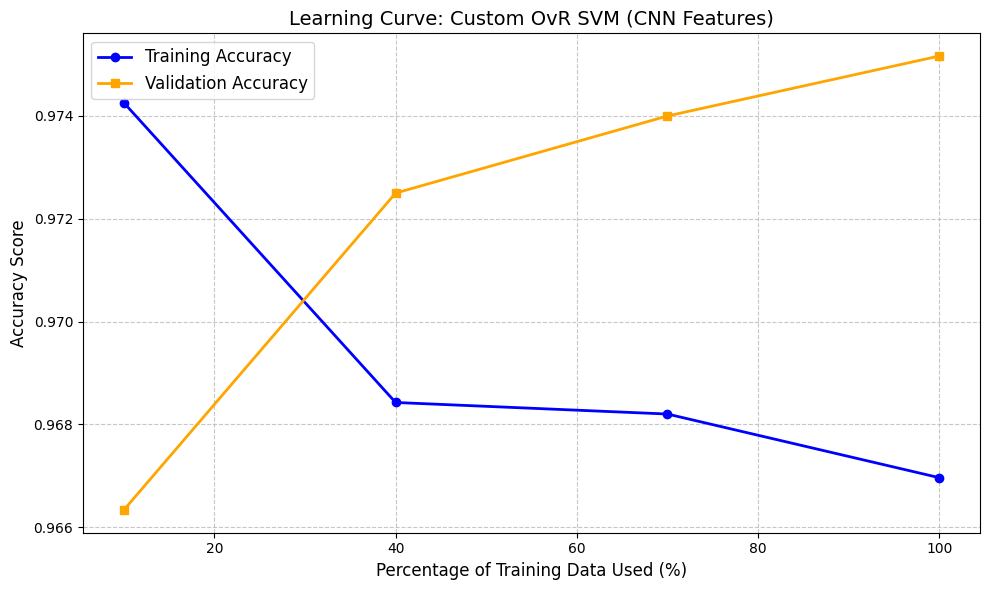

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing2 import custom_accuracy_score,cnn



X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="hog")
train_fractions = np.linspace(0.1, 1.0, 4)
train_scores = []
val_scores = []

total_train_samples = len(X_train)

for fraction in train_fractions:
    subset_size = int(total_train_samples * fraction)
    print(f"Training on {subset_size} samples ({int(fraction*100)}%)...")
    
    X_subset = X_train[:subset_size]
    y_subset = y_train[:subset_size]
    
    # changable for each model
    curve_model = OneVsRestSVM(
        n_classes=10, 
        learning_rate=0.001, 
        lambda_param=0.0001, 
        n_iters=500
    )
    
    curve_model.fit(X_subset, y_subset)
    
    train_preds = curve_model.predict(X_subset)
    val_preds = curve_model.predict(X_val)
    
    train_scores.append(custom_accuracy_score(y_subset, train_preds))
    val_scores.append(custom_accuracy_score(y_val, val_preds))


plt.figure(figsize=(10, 6))
plt.plot(train_fractions * 100, train_scores, label="Training Accuracy", color="blue", marker="o", linewidth=2)
plt.plot(train_fractions * 100, val_scores, label="Validation Accuracy", color="orange", marker="s", linewidth=2)

plt.title("Learning Curve: Custom OvR SVM (CNN Features)", fontsize=14)
plt.xlabel("Percentage of Training Data Used (%)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()